### Notebook Purpose: TCN + Baseline Hybrid
- Train a PyTorch Hurdle TCN mirroring the ML experiment on 15-minute windows
- Stream per-ID windows via shared window_index and cache directories
- Fit active/log-volume heads, tune threshold on validation, then run the final test
- Save checkpoints, metrics, and plots to the relevant `results/` folders

### Note
- Shared inputs/outputs and execution conventions are documented in the project README.


In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Minimal environment setup to keep the notebook focused on the core experiments.
# If you run this elsewhere, update PROJECT_DIR accordingly.
PROJECT_DIR = Path("/content/drive/MyDrive/0.Portfolio/electricity_price_forecasting").resolve()


In [ ]:
project_str = str(PROJECT_DIR)
if project_str not in sys.path:
    sys.path.insert(0, project_str)

DATA_DIR         = PROJECT_DIR / "data"
RESULTS_DIR      = PROJECT_DIR / "results"
METRICS_DIR      = RESULTS_DIR / "metrics"
MODELS_DIR       = RESULTS_DIR / "models"
WINDOW_INDEX_DIR = RESULTS_DIR / "window_index"
LOGS_DIR         = RESULTS_DIR / "logs"
CACHE_DIR        = RESULTS_DIR / "cache"
PLOTS_DIR        = RESULTS_DIR / "plots"

for p in [
    RESULTS_DIR,
    PLOTS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    WINDOW_INDEX_DIR,
    LOGS_DIR,
    CACHE_DIR,
    PLOTS_DIR / "models",
    PLOTS_DIR / "eval/curves",
    PLOTS_DIR / "eval/tables",
    PLOTS_DIR / "eda",
    PLOTS_DIR / "feature_engineering",
]:
    p.mkdir(parents=True, exist_ok=True)


# 04_TCN_Baseline_hybrid.ipynb (Final)

This notebook trains a Hurdle-TCN in PyTorch and compares it to the persistence baseline under the exact same window_index / split / evaluation rules used by the ML notebook.

## Setup

## Load window_index

In [17]:
# === ID mapping and window index ===

import time
import numpy as np
import pandas as pd

from electricity_forecasting.io.id_mapping import (
    load_id_mapping_json,
    save_id_mapping_json,
    scan_unique_ids_from_parquet,
    build_id_mapping,
)
from electricity_forecasting.datasets.window_index_builder import build_window_indices
from electricity_forecasting.evaluation.evaluate import load_window_index, save_window_index, hash_window_index
from electricity_forecasting.config import WIN, HORIZON, MAX_TEST_WINDOWS, FREQ

# Optional constants (fallbacks keep the notebook runnable if config is older)
try:
    from electricity_forecasting.config import MAX_TRAIN_WINDOWS, MAX_VAL_WINDOWS, VALID_RATIO
except Exception:
    MAX_TRAIN_WINDOWS = 300_000
    MAX_VAL_WINDOWS = 100_000
    VALID_RATIO = 0.1

# Fixed time bounds (UTC)
TRAIN_START = pd.Timestamp("2021-01-01 00:00:00", tz="UTC")
TRAIN_END   = pd.Timestamp("2023-12-31 23:45:00", tz="UTC")
TEST_START  = pd.Timestamp("2024-01-01 00:00:00", tz="UTC")
TEST_END    = pd.Timestamp("2024-12-31 23:45:00", tz="UTC")

print("Time bounds fixed (UTC).")

# Stable ID mapping cache
ID_MAP_PATH = RESULTS_DIR / "window_index" / "id_code_mapping.json"
if ID_MAP_PATH.exists():
    id_to_code, code_to_id, all_codes = load_id_mapping_json(ID_MAP_PATH)
    print("OK: Loaded cached ID mapping | n_ids:", len(all_codes))
else:
    t0 = time.time()
    ids_raw = scan_unique_ids_from_parquet(str(TEST_PARQUET), id_col="ID")
    id_to_code, code_to_id, all_codes = build_id_mapping(ids_raw)
    save_id_mapping_json(ID_MAP_PATH, id_to_code=id_to_code, code_to_id=code_to_id)
    print("OK: Built + saved ID mapping | n_ids:", len(all_codes), "| elapsed:", f"{(time.time()-t0):.1f}s")

# Canonical window_index cache (same filenames as the ML notebook)
p_tr = RESULTS_DIR / "window_index" / f"train_windows_all_ids_cap{int(MAX_TRAIN_WINDOWS)}.csv"
p_va = RESULTS_DIR / "window_index" / f"val_windows_all_ids_cap{int(MAX_VAL_WINDOWS)}.csv"
p_te = RESULTS_DIR / "window_index" / f"test_windows_all_ids_cap{int(MAX_TEST_WINDOWS)}.csv"

def _cap_windows_id_balanced(wi: pd.DataFrame, cap: int | None) -> pd.DataFrame:
    """Deterministic, ID-balanced cap on an existing window_index."""
    if cap is None:
        return wi
    cap = int(cap)
    if cap <= 0 or len(wi) <= cap:
        return wi

    wi = wi[["ID", "start_pos"]].copy()
    wi["ID"] = wi["ID"].astype(np.int64)
    wi["start_pos"] = wi["start_pos"].astype(np.int64)
    wi = wi.sort_values(["ID", "start_pos"]).reset_index(drop=True)

    ids = wi["ID"].unique()
    n_ids = int(ids.size)
    base = cap // n_ids
    rem = cap % n_ids

    parts = []
    for i, _id in enumerate(ids):
        k = base + (1 if i < rem else 0)
        parts.append(wi[wi["ID"] == _id].head(k))

    out = pd.concat(parts, ignore_index=True)

    # Fill remainder deterministically if some IDs have fewer than allocated
    if len(out) < cap:
        used = set(map(tuple, out[["ID", "start_pos"]].to_numpy().tolist()))
        extra = []
        for r in wi.itertuples(index=False):
            key = (int(r.ID), int(r.start_pos))
            if key in used:
                continue
            extra.append({"ID": int(r.ID), "start_pos": int(r.start_pos)})
            if len(out) + len(extra) >= cap:
                break
        if extra:
            out = pd.concat([out, pd.DataFrame(extra)], ignore_index=True)

    out = out.sort_values(["ID", "start_pos"]).reset_index(drop=True)
    return out

# Load cached indices or build deterministically
if p_tr.exists() and p_va.exists() and p_te.exists():
    w_tr = load_window_index(p_tr)
    w_va = load_window_index(p_va)
    w_te = load_window_index(p_te)
    print("OK: Loaded cached window_index files.")
else:
    w_tr, w_va, w_te, _meta = build_window_indices(
        all_id_codes=list(all_codes),
        train_start_utc=TRAIN_START,
        train_end_utc=TRAIN_END,
        test_start_utc=TEST_START,
        test_end_utc=TEST_END,
        win=int(WIN),
        horizon=int(HORIZON),
        freq=str(FREQ),
        max_train_windows=int(MAX_TRAIN_WINDOWS),
        max_val_windows=int(MAX_VAL_WINDOWS),
        max_test_windows=int(MAX_TEST_WINDOWS),
        valid_ratio=float(VALID_RATIO),
        seed=int(globals().get("SEED", 42)),
    )
    save_window_index(w_tr, p_tr)
    save_window_index(w_va, p_va)
    save_window_index(w_te, p_te)
    print("OK: Built + saved window_index files.")

# Optional dev caps (kept deterministic and ID-balanced)
w_tr = _cap_windows_id_balanced(w_tr, globals().get("SUBSAMPLE_TRAIN_WINDOWS", None))
w_va = _cap_windows_id_balanced(w_va, globals().get("SUBSAMPLE_VAL_WINDOWS", None))
w_te = _cap_windows_id_balanced(w_te, globals().get("SUBSAMPLE_TEST_WINDOWS", None))

# Sanity
print("w_tr:", w_tr.shape, "| n_ids:", int(w_tr["ID"].nunique()))
print("w_va:", w_va.shape, "| n_ids:", int(w_va["ID"].nunique()))
print("w_te:", w_te.shape, "| n_ids:", int(w_te["ID"].nunique()))
print("n_test_windows_used:", int(len(w_te)), "| cap:", int(MAX_TEST_WINDOWS))

print("window_index hashes:")
print("  train:", hash_window_index(w_tr)[:16], "...")
print("  val  :", hash_window_index(w_va)[:16], "...")
print("  test :", hash_window_index(w_te)[:16], "...")


Time bounds fixed (UTC).
OK: Loaded cached ID mapping | n_ids: 672
OK: Loaded cached window_index files.
w_tr: (300000, 2) | n_ids: 672
w_va: (100000, 2) | n_ids: 672
w_te: (200000, 2) | n_ids: 672
n_test_windows_used: 200000 | cap: 200000
window_index hashes:
  train: f68a7c486e7eb049 ...
  val  : c376472b20209188 ...
  test : 005f0255eeb9af52 ...


## Build ID mapping and fix time bounds

In [18]:
# === Reproducibility checks ===

from electricity_forecasting.config import WIN, HORIZON, MAX_TEST_WINDOWS
try:
    from electricity_forecasting.config import MAX_TRAIN_WINDOWS, MAX_VAL_WINDOWS, VALID_RATIO
except Exception:
    MAX_TRAIN_WINDOWS = 300_000
    MAX_VAL_WINDOWS = 100_000
    VALID_RATIO = 0.1

print("WIN:", int(WIN))
print("HORIZON:", int(HORIZON))
print("MAX_TRAIN_WINDOWS:", int(MAX_TRAIN_WINDOWS))
print("MAX_VAL_WINDOWS:", int(MAX_VAL_WINDOWS))
print("MAX_TEST_WINDOWS:", int(MAX_TEST_WINDOWS))
print("VALID_RATIO:", float(VALID_RATIO))

print("n_ids_total (mapping):", int(len(all_codes)))
print("n_ids_train:", int(w_tr["ID"].nunique()))
print("n_ids_val  :", int(w_va["ID"].nunique()))
print("n_ids_test :", int(w_te["ID"].nunique()))

max_code_in_windows = int(max(w_te["ID"].max(), w_tr["ID"].max(), w_va["ID"].max()))
assert max_code_in_windows < len(all_codes), "window_index contains an ID code outside the mapping."

print("OK: window_index ID codes are within mapping range.")
print("n_test_windows_used:", int(len(w_te)), "(must be <= MAX_TEST_WINDOWS)")


WIN: 128
HORIZON: 10
MAX_TRAIN_WINDOWS: 300000
MAX_VAL_WINDOWS: 100000
MAX_TEST_WINDOWS: 200000
VALID_RATIO: 0.1
n_ids_total (mapping): 672
n_ids_train: 672
n_ids_val  : 672
n_ids_test : 672
OK: window_index ID codes are within mapping range.
n_test_windows_used: 200000 (must be <= MAX_TEST_WINDOWS)


## Dataset materialize (streaming)

In [19]:
# === Dataset materialization ===

# Note: We do NOT materialize (N, WIN, F) for train to avoid multi-GB memory usage.

# Infer feature columns from a single sample ID grid
sample_code = int(w_tr["ID"].iloc[0])
sample_raw_id = code_to_id[sample_code]

df_grid_sample = build_one_id_grid_with_features(
    parquet_path=str(TRAIN_PARQUET),
    raw_id=sample_raw_id,
    id_code=sample_code,
    start_utc=TRAIN_START,
    end_utc=TRAIN_END,
    freq=FREQ,
    berlin_tz=BERLIN_TZ,
)
feature_cols = infer_feature_cols(df_grid_sample)
target_cols = list(TARGET_COLS)

# Validate NaNs (must be clean)
assert not df_grid_sample[feature_cols].isna().any().any(), "NaNs found in feature columns."
assert not df_grid_sample[target_cols].isna().any().any(), "NaNs found in target columns."

print("n_features:", len(feature_cols))
print("feature_cols:", feature_cols)

class PerIDWindowIterableDataset(IterableDataset):
    """
    RAM-safe iterable dataset that:
    - groups window_index by ID
    - loads one ID grid at a time from parquet
    - yields canonical (X_seq, Y_true) windows

    X_seq: (WIN, n_features)
    Y_true: (HORIZON, n_targets)
    Optionally yields Y_base (persistence baseline) when return_baseline=True.
    """
    def __init__(
        self,
        *,
        parquet_path: str,
        window_index: pd.DataFrame,
        code_to_id: dict,
        start_utc: pd.Timestamp,
        end_utc: pd.Timestamp,
        win: int,
        horizon: int,
        feature_cols: list[str],
        target_cols: list[str],
        freq: str,
        berlin_tz: str,
        seed: int = 42,
        shuffle_ids: bool = False,
        shuffle_within_id: bool = False,
        return_baseline: bool = False,
    ):
        super().__init__()
        self.parquet_path = str(parquet_path)
        self.start_utc = start_utc
        self.end_utc = end_utc
        self.win = int(win)
        self.horizon = int(horizon)
        self.feature_cols = list(feature_cols)
        self.target_cols = list(target_cols)
        self.freq = str(freq)
        self.berlin_tz = str(berlin_tz)
        self.code_to_id = dict(code_to_id)
        self.seed = int(seed)
        self.shuffle_ids = bool(shuffle_ids)
        self.shuffle_within_id = bool(shuffle_within_id)
        self.return_baseline = bool(return_baseline)

        wi = window_index.copy()
        wi["ID"] = wi["ID"].astype(np.int64)
        wi["start_pos"] = wi["start_pos"].astype(np.int64)
        wi = wi.sort_values(["ID", "start_pos"]).reset_index(drop=True)

        self.id_list = wi["ID"].unique().astype(np.int64).tolist()
        self.starts_by_id = {
            int(_id): wi.loc[wi["ID"] == _id, "start_pos"].to_numpy(dtype=np.int64, copy=False)
            for _id in self.id_list
        }

        self._epoch = 0

    def set_epoch(self, epoch: int) -> None:
        self._epoch = int(epoch)

    def __iter__(self):
        # Support multi-worker loading: split IDs across workers deterministically
        worker = torch.utils.data.get_worker_info()
        if worker is None:
            worker_id = 0
            num_workers = 1
        else:
            worker_id = worker.id
            num_workers = worker.num_workers

        ids = list(self.id_list)
        # Shuffling policy (deterministic per epoch)
        rng = np.random.default_rng(self.seed + 10_000 * self._epoch + worker_id)

        if self.shuffle_ids:
            rng.shuffle(ids)
        else:
            ids = sorted(ids)

        # Worker shard: take every num_workers-th ID
        ids = ids[worker_id::num_workers]

        for id_code in ids:
            raw_id = self.code_to_id[int(id_code)]
            df_grid = build_one_id_grid_with_features(
                parquet_path=self.parquet_path,
                raw_id=raw_id,
                id_code=int(id_code),
                start_utc=self.start_utc,
                end_utc=self.end_utc,
                freq=self.freq,
                berlin_tz=self.berlin_tz,
            )

            feat = df_grid[self.feature_cols].to_numpy(dtype=np.float32, copy=False)
            tgt = df_grid[self.target_cols].to_numpy(dtype=np.float32, copy=False)

            starts = self.starts_by_id[int(id_code)]
            if self.shuffle_within_id:
                starts = starts.copy()
                rng.shuffle(starts)

            for start_pos in starts.tolist():
                start_pos = int(start_pos)
                x = feat[start_pos : start_pos + self.win, :]  # (WIN, F)
                y = tgt[start_pos + self.win : start_pos + self.win + self.horizon, :]  # (H, C)

                x_t = torch.from_numpy(np.asarray(x, dtype=np.float32))
                y_t = torch.from_numpy(np.asarray(y, dtype=np.float32))

                if not self.return_baseline:
                    yield x_t, y_t
                else:
                    last = tgt[start_pos + self.win - 1, :]  # (C,)
                    y_base = np.repeat(last.reshape(1, -1), repeats=self.horizon, axis=0).astype(np.float32)
                    yb_t = torch.from_numpy(y_base)
                    yield x_t, y_t, yb_t

# DataLoaders
train_ds = PerIDWindowIterableDataset(
    parquet_path=str(TRAIN_PARQUET),
    window_index=w_tr,
    code_to_id=code_to_id,
    start_utc=TRAIN_START,
    end_utc=TRAIN_END,
    win=WIN,
    horizon=HORIZON,
    feature_cols=feature_cols,
    target_cols=target_cols,
    freq=FREQ,
    berlin_tz=BERLIN_TZ,
    seed=SEED,
    shuffle_ids=True,
    shuffle_within_id=True,
    return_baseline=False,
)

val_ds = PerIDWindowIterableDataset(
    parquet_path=str(TRAIN_PARQUET),
    window_index=w_va,
    code_to_id=code_to_id,
    start_utc=TRAIN_START,
    end_utc=TRAIN_END,
    win=WIN,
    horizon=HORIZON,
    feature_cols=feature_cols,
    target_cols=target_cols,
    freq=FREQ,
    berlin_tz=BERLIN_TZ,
    seed=SEED,
    shuffle_ids=False,
    shuffle_within_id=False,
    return_baseline=True,
)

test_ds = PerIDWindowIterableDataset(
    parquet_path=str(TEST_PARQUET),
    window_index=w_te,
    code_to_id=code_to_id,
    start_utc=TEST_START,
    end_utc=TEST_END,
    win=WIN,
    horizon=HORIZON,
    feature_cols=feature_cols,
    target_cols=target_cols,
    freq=FREQ,
    berlin_tz=BERLIN_TZ,
    seed=SEED,
    shuffle_ids=False,
    shuffle_within_id=False,
    return_baseline=True,
)

# DataLoader kwargs (pin_memory + non_blocking only matter on CUDA)
train_loader_kwargs = dict(
    batch_size=BATCH_SIZE_TRAIN,
    num_workers=NUM_WORKERS_TRAIN,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
if NUM_WORKERS_TRAIN > 0:
    train_loader_kwargs.update(dict(prefetch_factor=PREFETCH_FACTOR, persistent_workers=False))

eval_loader_kwargs = dict(
    batch_size=BATCH_SIZE_EVAL,
    num_workers=NUM_WORKERS_EVAL,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

train_loader = DataLoader(train_ds, **train_loader_kwargs)
val_loader   = DataLoader(val_ds, **eval_loader_kwargs)
test_loader  = DataLoader(test_ds, **eval_loader_kwargs)

# Sanity check: one batch
x0, y0 = next(iter(train_loader))
print("Train batch shapes:", x0.shape, y0.shape)  # (B, WIN, F), (B, H, C)


n_features: 13
feature_cols: ['logvol', 'logvol_lag1', 'logvol_lag2', 'logvol_rollmean_16', 'logvol_rollmean_4', 'close', 'high', 'low', 'dow_berlin', 'hour_berlin', 'hour_berlin_cos', 'hour_berlin_sin', 'month_berlin']
Train batch shapes: torch.Size([512, 128, 13]) torch.Size([512, 10, 4])


## Model train

In [20]:
# === Hurdle TCN model definition ===

import torch
import torch.nn as nn
import torch.nn.functional as F


class Chomp1d(nn.Module):
    """Remove padding to keep causal convolution output length."""
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = int(chomp_size)

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, in_ch: int, channels: list[int], kernel_size: int = 3, dropout: float = 0.1):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            in_c = in_ch if i == 0 else channels[i - 1]
            layers.append(TemporalBlock(in_c, out_ch, kernel_size=kernel_size, dilation=dilation, dropout=dropout))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class HurdleTCN(nn.Module):
    """
    Two-head hurdle TCN.

    Input:
      X: (B, WIN, F)

    Outputs:
      active_logits: (B, HORIZON)
      logvol_hat:    (B, HORIZON)  # predicts log1p(volume)
    """
    def __init__(
        self,
        n_features: int,
        horizon: int,
        channels: list[int] = [64, 64, 64, 64, 64],
        kernel_size: int = 3,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.horizon = int(horizon)

        self.in_norm = nn.LayerNorm(n_features)
        self.tcn = TemporalConvNet(in_ch=n_features, channels=channels, kernel_size=kernel_size, dropout=dropout)

        last_ch = int(channels[-1])
        self.head_active = nn.Linear(last_ch, self.horizon)
        self.head_logvol = nn.Linear(last_ch, self.horizon)

    def forward(self, x):
        # x: (B, WIN, F)
        x = self.in_norm(x)
        x = x.transpose(1, 2)  # (B, F, WIN)
        h = self.tcn(x)        # (B, C, WIN)
        h_last = h[:, :, -1]   # (B, C)

        active_logits = self.head_active(h_last)
        logvol_hat = self.head_logvol(h_last)
        return active_logits, logvol_hat

def huber_loss_per_elem(pred: torch.Tensor, target: torch.Tensor, delta: float = 1.0) -> torch.Tensor:
    """
    Huber loss per element, same shape as pred/target.
    """
    diff = pred - target
    abs_diff = torch.abs(diff)
    d = float(delta)
    return torch.where(abs_diff <= d, 0.5 * diff * diff, d * (abs_diff - 0.5 * d))

def masked_huber_loss(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor, delta: float = 1.0) -> torch.Tensor:
    """
    pred/target/mask: (B, H)
    mask is 1 for active positions, 0 for inactive.

    Returns mean loss over active positions; 0 if no active positions in batch.
    """
    per_elem = huber_loss_per_elem(pred, target, delta=delta)
    masked = per_elem * mask
    denom = mask.sum().clamp(min=1.0)
    return masked.sum() / denom

# -----------------------------
# Training loop
# -----------------------------
from torch.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = (device.type == "cuda")
USE_AMP = True  # set False to disable AMP

use_amp = bool(USE_CUDA and USE_AMP)
scaler = GradScaler("cuda", enabled=use_amp)

model = HurdleTCN(
    n_features=len(feature_cols),
    horizon=HORIZON,
    channels=CHANNELS,
    kernel_size=3,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}")

# Optional: class imbalance weighting for the active head.
# Keep disabled by default to avoid extra passes over the dataset.
USE_POS_WEIGHT = False
POS_WEIGHT = None

if USE_POS_WEIGHT:
    # Estimate pos_weight from a small sample of the training stream.
    # pos_weight = (#neg / #pos), computed on active mask from ground-truth volume.
    pos = 0.0
    neg = 0.0
    n_seen = 0
    for i, (xb, yb) in enumerate(train_loader):
        y_vol = yb[:, :, VOLUME_INDEX]
        y_act = (y_vol > 0).float()
        pos += float(y_act.sum().item())
        neg += float(y_act.numel() - y_act.sum().item())
        n_seen += 1
        if n_seen >= 100:
            break
    if pos > 0:
        POS_WEIGHT = torch.tensor([neg / pos], dtype=torch.float32, device=device)
        print("Estimated POS_WEIGHT:", float(POS_WEIGHT.item()))
    else:
        print("POS_WEIGHT estimation skipped (no positives found in sample).")

bce = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def run_one_epoch_train(epoch: int) -> dict:
    model.train()
    train_ds.set_epoch(epoch)

    n_batches = 0
    loss_sum = 0.0
    loss_cls_sum = 0.0
    loss_reg_sum = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)  # (B, WIN, F)
        yb = yb.to(device, non_blocking=True)  # (B, H, C)

        y_vol = yb[:, :, VOLUME_INDEX]  # (B, H)
        y_active = (y_vol > 0).float()
        y_logvol = torch.log1p(torch.clamp(y_vol, min=0.0))

        opt.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp):
            active_logits, logvol_hat = model(xb)
            # Compute losses in fp32 for stability
            loss_cls = bce(active_logits.float(), y_active)
            loss_reg = masked_huber_loss(logvol_hat.float(), y_logvol, y_active, delta=HUBER_DELTA)
            loss = loss_cls + LAMBDA_REG * loss_reg

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            opt.step()

        n_batches += 1
        loss_sum += float(loss.detach().cpu())
        loss_cls_sum += float(loss_cls.detach().cpu())
        loss_reg_sum += float(loss_reg.detach().cpu())

    return {
        "train_loss": loss_sum / max(1, n_batches),
        "train_loss_cls": loss_cls_sum / max(1, n_batches),
        "train_loss_reg": loss_reg_sum / max(1, n_batches),
        "n_batches": int(n_batches),
    }

@torch.no_grad()
def run_one_epoch_val() -> dict:
    model.eval()

    n_batches = 0
    loss_sum = 0.0
    loss_cls_sum = 0.0
    loss_reg_sum = 0.0

    for xb, yb, _yb_base in val_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        y_vol = yb[:, :, VOLUME_INDEX]
        y_active = (y_vol > 0).float()
        y_logvol = torch.log1p(torch.clamp(y_vol, min=0.0))

        with autocast("cuda", enabled=use_amp):
            active_logits, logvol_hat = model(xb)
            loss_cls = bce(active_logits.float(), y_active)
            loss_reg = masked_huber_loss(logvol_hat.float(), y_logvol, y_active, delta=HUBER_DELTA)
            loss = loss_cls + LAMBDA_REG * loss_reg

        n_batches += 1
        loss_sum += float(loss.detach().cpu())
        loss_cls_sum += float(loss_cls.detach().cpu())
        loss_reg_sum += float(loss_reg.detach().cpu())

    return {
        "val_loss": loss_sum / max(1, n_batches),
        "val_loss_cls": loss_cls_sum / max(1, n_batches),
        "val_loss_reg": loss_reg_sum / max(1, n_batches),
        "n_batches": int(n_batches),
    }

best_val = float("inf")
best_state = None
no_improve = 0

print("Starting training...")
for epoch in range(EPOCHS):
    t0 = time.time()
    tr_stats = run_one_epoch_train(epoch)
    va_stats = run_one_epoch_val()
    dt = time.time() - t0

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train={tr_stats['train_loss']:.4f} (cls={tr_stats['train_loss_cls']:.4f}, reg={tr_stats['train_loss_reg']:.4f}) | "
        f"val={va_stats['val_loss']:.4f} (cls={va_stats['val_loss_cls']:.4f}, reg={va_stats['val_loss_reg']:.4f}) | "
        f"time={dt/60:.1f} min"
    )

    if va_stats["val_loss"] < best_val:
        best_val = va_stats["val_loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping: no improvement for {PATIENCE} epochs.")
            break

assert best_state is not None, "Best model state was not captured."
model.load_state_dict(best_state)
print("OK: Loaded best model by validation loss.")


Model params: 66,542
Starting training...
Epoch 01/6 | train=0.6137 (cls=0.1201, reg=0.4936) | val=0.5984 (cls=0.1026, reg=0.4957) | time=14.1 min
Epoch 02/6 | train=0.5395 (cls=0.1035, reg=0.4359) | val=0.4861 (cls=0.0985, reg=0.3876) | time=14.1 min
Epoch 03/6 | train=0.5070 (cls=0.1023, reg=0.4047) | val=0.5577 (cls=0.0956, reg=0.4621) | time=14.1 min
Epoch 04/6 | train=0.4852 (cls=0.1002, reg=0.3849) | val=0.4551 (cls=0.0950, reg=0.3601) | time=14.0 min
Epoch 05/6 | train=0.4795 (cls=0.0990, reg=0.3805) | val=0.4680 (cls=0.0902, reg=0.3778) | time=14.1 min
Epoch 06/6 | train=0.4783 (cls=0.0996, reg=0.3787) | val=0.4788 (cls=0.0993, reg=0.3795) | time=14.0 min
Early stopping: no improvement for 2 epochs.
OK: Loaded best model by validation loss.


## Validation threshold sweep

Collected validation outputs: (100000, 10) (100000, 10) (100000, 10) (477.1s)
Best threshold (selected on validation): 0.6499999761581421
Saved: dl_hurdle_tcn_threshold_sweep_volume.png


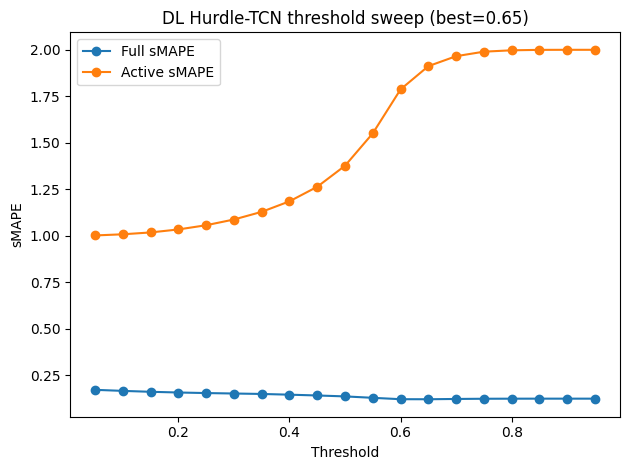

In [22]:
# === Validation threshold sweep ===

import torch
from torch.amp import autocast

@torch.no_grad()
def collect_hurdle_outputs(loader: DataLoader) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      y_true_vol: (N, H)
      proba:      (N, H)
      logvol_hat: (N, H)
    """
    model.eval()

    y_list = []
    p_list = []
    z_list = []

    for xb, yb, _yb_base in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        y_vol = yb[:, :, VOLUME_INDEX]  # (B, H)

        with autocast(device_type="cuda", enabled=use_amp):
          active_logits, logvol_hat = model(xb)

        proba = torch.sigmoid(active_logits.float())
        y_list.append(y_vol.detach().cpu().numpy().astype(np.float32))
        p_list.append(proba.detach().cpu().numpy().astype(np.float32))
        z_list.append(logvol_hat.float().detach().cpu().numpy().astype(np.float32))

    y_true_vol = np.concatenate(y_list, axis=0)
    proba_all = np.concatenate(p_list, axis=0)
    logvol_all = np.concatenate(z_list, axis=0)
    return y_true_vol, proba_all, logvol_all

t0 = time.time()
y_va_vol, proba_va, logvol_va = collect_hurdle_outputs(val_loader)
print("Collected validation outputs:", y_va_vol.shape, proba_va.shape, logvol_va.shape, f"({time.time()-t0:.1f}s)")

best_thr, sweep_df = threshold_sweep_on_validation(
    y_true_vol_va=y_va_vol,
    proba_va=proba_va,
    logvol_va=logvol_va,
    thresholds=THRESHOLDS,
)

print("Best threshold (selected on validation):", float(best_thr))

# Prepare curve for plotting (volume-only)
curve_df = pd.DataFrame({
    "threshold": sweep_df["threshold"].astype(float),
    "full_smape": sweep_df["val_full_smape_volume"].astype(float),
    "active_smape": sweep_df["val_active_smape_volume"].astype(float),
})

fig = plot_threshold_sweep(curve_df, title=f"DL Hurdle-TCN threshold sweep (best={best_thr:.2f})")
curve_path = PLOTS_DIR / "eval/curves" / "dl_hurdle_tcn_threshold_sweep_volume.png"
save_fig(curve_path, fig=fig, dpi=160)
print("Saved:", curve_path.name)

threshold_info = {
    "threshold_grid": [float(x) for x in THRESHOLDS.tolist()],
    "val_volume_full_smape_curve": [float(x) for x in curve_df["full_smape"].tolist()],
    "val_volume_active_smape_curve": [float(x) for x in curve_df["active_smape"].tolist()],
    "threshold_selected": float(best_thr),
    "threshold_selected_on": "validation",
    "metric_optimized": "volume_full_smape_on_validation",
}


## Test evaluation and save artifacts

In [26]:
# === Test evaluation and artifact export ===

from torch.amp import autocast

@torch.no_grad()
def collect_test_tensors(loader: DataLoader, threshold: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      Y_true: (N, H, C)
      Y_base: (N, H, C)  # persistence baseline (all targets)
      vol_hat: (N, H)    # model volume-only prediction
    """
    model.eval()

    yt_list = []
    yb_list = []
    vh_list = []

    for xb, yb, yb_base in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        yb_base = yb_base.to(device, non_blocking=True)

        with autocast("cuda", enabled=use_amp):
            active_logits, logvol_hat = model(xb)

        proba = torch.sigmoid(active_logits.float())  # (B, H)
        vol_reg = torch.expm1(logvol_hat.float()).clamp(min=0.0)  # (B, H)
        gate = (proba >= float(threshold)).float()
        vol_hat = gate * vol_reg

        yt_list.append(yb.detach().cpu().numpy().astype(np.float32))
        yb_list.append(yb_base.detach().cpu().numpy().astype(np.float32))
        vh_list.append(vol_hat.detach().cpu().numpy().astype(np.float32))

    Y_true = np.concatenate(yt_list, axis=0)
    Y_base = np.concatenate(yb_list, axis=0)
    vol_hat = np.concatenate(vh_list, axis=0)
    return Y_true, Y_base, vol_hat

# Collect test tensors once
t0 = time.time()
Y_te, Yb_te, vol_hat_te = collect_test_tensors(test_loader, threshold=float(best_thr))
print("Collected test tensors:", Y_te.shape, Yb_te.shape, vol_hat_te.shape, f"({time.time()-t0:.1f}s)")

# Baseline predictions (persistence)
Y_pred_baseline = Yb_te.astype(np.float32)

# Model predictions: keep prices from baseline, replace volume only
Y_pred_model = Yb_te.copy().astype(np.float32)
Y_pred_model[:, :, VOLUME_INDEX] = vol_hat_te.astype(np.float32)

# Canonical metrics (flatten sMAPE)
baseline_metrics = evaluate_predictions(Y_true=Y_te, Y_pred=Y_pred_baseline, volume_index=VOLUME_INDEX)
model_metrics    = evaluate_predictions(Y_true=Y_te, Y_pred=Y_pred_model,    volume_index=VOLUME_INDEX)

print("Baseline Full/Active:", baseline_metrics)
print("Model    Full/Active:", model_metrics)

active_ratio = active_ratio_from_truth(Y_te, volume_index=VOLUME_INDEX)
print("Active ratio (test):", float(active_ratio))

# Bar chart: baseline vs model (canonical)
metrics_bar = {
    "baseline_full": float(baseline_metrics["full_smape"]),
    "baseline_active": float(baseline_metrics["active_smape"]),
    "model_full": float(model_metrics["full_smape"]),
    "model_active": float(model_metrics["active_smape"]),
}

bar_path = PLOTS_DIR / "models/dl_hurdle_tcn" / "dl_hurdle_tcn_vs_baseline_bar.png"
plot_and_save_baseline_vs_model_bar(
    metrics_bar=metrics_bar,
    out_png=str(bar_path),
    title="DL Hurdle TCN vs Baseline (canonical metrics)",
    dpi=160,
)
print("Saved:", bar_path.name)

# Metrics JSON (standard schema)
run_tag = "dl_hurdle_tcn_all_ids_window_based"

sampling_info = {
    "n_train_windows_used": int(len(w_tr)),
    "n_val_windows_used": int(len(w_va)),
    "n_test_windows_used": int(len(w_te)),
    "n_ids_train": int(w_tr["ID"].nunique()),
    "n_ids_val": int(w_va["ID"].nunique()),
    "n_ids_test": int(w_te["ID"].nunique()),
    "window_index_paths": {"train": p_tr.name, "val": p_va.name, "test": p_te.name},
    "window_index_hashes": {
        "train": hash_window_index(w_tr),
        "val": hash_window_index(w_va),
        "test": hash_window_index(w_te),
    },
    "window_index_format": "(ID_code, start_pos)",
    "sampling_rule": "window_index (same as ML experiment); validation time-based; no test leakage",
}

split_info = {
    "train_period": "2021-01-01 .. 2023-12-31 (UTC)",
    "test_period": "2024-01-01 .. 2024-12-31 (UTC)",
    "validation_sampling": "within train period (time-based last 10%) using the pre-built window_index",
    "threshold_selection": "validation_only",
    "test_evaluation": "single_pass",
}

constants = {
    "WIN": int(WIN),
    "HORIZON": int(HORIZON),
    "MAX_TEST_WINDOWS": int(MAX_TEST_WINDOWS),
    "TARGET_COLS": list(TARGET_COLS),
    "VOLUME_INDEX": int(VOLUME_INDEX),
    "FREQ": str(FREQ),
    "FEATURE_COLS": list(feature_cols) if "feature_cols" in globals() else [],
}

extra = {
    "runtime": {
        "device": str(device),
        "use_amp": bool(use_amp),
        "use_tf32": bool(USE_CUDA and USE_TF32),
        "deterministic": bool(DETERMINISTIC),
        "num_workers_train": int(NUM_WORKERS_TRAIN),
        "num_workers_eval": int(NUM_WORKERS_EVAL),
        "pin_memory": bool(PIN_MEMORY),
    },
    "training": {
        "epochs_planned": int(EPOCHS),
        "patience": int(PATIENCE),
        "batch_size_train": int(BATCH_SIZE_TRAIN),
        "batch_size_eval": int(BATCH_SIZE_EVAL),
        "lr": float(LR),
        "weight_decay": float(WEIGHT_DECAY),
        "dropout": float(DROPOUT),
        "lambda_reg": float(LAMBDA_REG),
        "huber_delta": float(HUBER_DELTA),
        "grad_clip": float(GRAD_CLIP),
        "channels": list(CHANNELS),
    },
    "fast_dev_run": bool(FAST_DEV_RUN),
}

record = build_metrics_record(
    model_name="dl_hurdle_tcn",
    run_tag=run_tag,
    constants=constants,
    split_info=split_info,
    sampling_info=sampling_info,
    baseline_metrics=baseline_metrics,
    model_metrics=model_metrics,
    active_ratio_test=float(active_ratio),
    threshold_info=threshold_info,
    extra=extra,
)

out_json = RESULTS_DIR / "metrics" / "dl_hurdle_tcn.json"
save_metrics_record(record, out_json)
print("Saved metrics JSON:", out_json.name)

shapes = {
    "Y_te": list(Y_te.shape),
    "Yb_te": list(Yb_te.shape),
    "vol_hat_te": list(vol_hat_te.shape),
}
log_run_header(
    model_name=record["model_name"],
    constants=record["constants"],
    shapes=shapes,
    sampling_info=record["sampling_info"],
)

# Metrics table (per-target Full/Active) + save CSV/JSON/PNG
preds = {
    "1. Baseline (Persistence)": Y_pred_baseline,
    "2. DL Hurdle TCN": Y_pred_model,
}

df_tbl = make_metrics_table(
    Y_true=Y_te,
    preds=preds,
    target_cols=TARGET_COLS,
    volume_index=VOLUME_INDEX,
    model_order=["1. Baseline (Persistence)", "2. DL Hurdle TCN"],
)

display(df_tbl)

tbl_csv = RESULTS_DIR / "metrics" / "metrics_table_dl_hurdle_tcn_vs_baseline.csv"
tbl_json = RESULTS_DIR / "metrics" / "metrics_table_dl_hurdle_tcn_vs_baseline.json"
tbl_png = PLOTS_DIR / "eval/tables" / "metrics_table_dl_hurdle_tcn_vs_baseline.png"

save_metrics_table(df_tbl, tbl_csv, tbl_json)
save_metrics_table_figure(df_tbl, tbl_png, title="DL Hurdle TCN vs Baseline (F/Active sMAPE)", dpi=200)
print("Saved:", tbl_csv.name)
print("Saved:", tbl_json.name)
print("Saved:", tbl_png.name)


Collected test tensors: (200000, 10, 4) (200000, 10, 4) (200000, 10) (135.2s)
Baseline Full/Active: {'full_smape': 0.04316420980136336, 'active_smape': 0.5091056927381381}
Model    Full/Active: {'full_smape': 0.04404537264779705, 'active_smape': 0.6547969095196147}
Active ratio (test): 0.0458395
Saved: dl_hurdle_tcn_vs_baseline_bar.png
Saved metrics JSON: dl_hurdle_tcn.json
=== RUN HEADER ===
Model: dl_hurdle_tcn
Constants: {'WIN': 128, 'HORIZON': 10, 'MAX_TEST_WINDOWS': 200000, 'TARGET_COLS': ['high', 'low', 'close', 'volume'], 'VOLUME_INDEX': 3, 'FREQ': '15min', 'FEATURE_COLS': ['logvol', 'logvol_lag1', 'logvol_lag2', 'logvol_rollmean_16', 'logvol_rollmean_4', 'close', 'high', 'low', 'dow_berlin', 'hour_berlin', 'hour_berlin_cos', 'hour_berlin_sin', 'month_berlin']}
Shapes: {'Y_te': [200000, 10, 4], 'Yb_te': [200000, 10, 4], 'vol_hat_te': [200000, 10]}
Sampling: {'n_train_windows_used': 300000, 'n_val_windows_used': 100000, 'n_test_windows_used': 200000, 'n_ids_train': 672, 'n_ids_va

,Model,Active High,Active Low,Active Close,Active Volume,Active Total,Full High,Full Low,Full Close,Full Volume,Full Total
0,1. Baseline (Persistence),0.227735,0.23061,0.231246,1.346832,0.509106,0.02761,0.02789,0.027855,0.089302,0.043164
1,2. DL Hurdle TCN,0.227735,0.23061,0.231246,1.929596,0.654797,0.02761,0.02789,0.027855,0.092827,0.044045


Saved: metrics_table_dl_hurdle_tcn_vs_baseline.csv
Saved: metrics_table_dl_hurdle_tcn_vs_baseline.json
Saved: metrics_table_dl_hurdle_tcn_vs_baseline.png
